In [1]:
# ── 0. Imports & Config ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Directories (notebook lives in Notebooks/Supervised/ -> repo root is two up)
PROCESSED_DIR  = Path("../../Data/Processed")
MODELS_DIR     = Path("../../Models")
FIGURES_DIR    = Path("../../Figures/Supervised_Outputs")
PROCESSED_DIR2 = Path("../../Data/Processed/Supervised_Outputs")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = [
    "linear_svm",
    "kernel_svm",
    "cart",
    "random_forest",
    "bagging",
    "knn",
    "naive_bayes",
]

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

In [2]:
# ── 1. Load datasets ──────────────────────────────────────────────────────────
df_simple = pd.read_csv(PROCESSED_DIR / "clothes_size_clean.csv")
df_rich   = pd.read_csv(PROCESSED_DIR / "renttherunway_clean.csv")

print("Simple dataset shape:", df_simple.shape)
print("RTR dataset shape:", df_rich.shape)

Simple dataset shape: (118871, 10)
RTR dataset shape: (192544, 23)


In [3]:
# ── 2. Prepare simple dataset ─────────────────────────────────────────────────
SIMPLE_FEATURES = ["weight_lbs", "age", "height_inches"]
SIMPLE_TARGET   = "fit_equiv_label"   # expected: 0=Small, 1=Fit, 2=Large

df_simple_model = df_simple[SIMPLE_FEATURES + [SIMPLE_TARGET]].dropna().copy()

X_simple = df_simple_model[SIMPLE_FEATURES].copy()
y_simple = df_simple_model[SIMPLE_TARGET].astype(int).copy()

# Optional label encoder for readable class names in reports
label_map = {0: "Small", 1: "Fit", 2: "Large"}
y_simple_str = y_simple.map(label_map)

print(f"Simple dataset usable rows: {len(df_simple_model):,}")
print("Simple class counts:")
print(y_simple.value_counts().sort_index())

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_simple
)

Simple dataset usable rows: 118,871
Simple class counts:
fit_equiv_label
0    31618
1    29496
2    57757
Name: count, dtype: int64


In [4]:
# ── 3. Load RTR rich-feature saved results ────────────────────────────────────
PROBA_COLS = ["prob_small", "prob_fit", "prob_large"]

def load_model_results(model_name):
    path = PROCESSED_DIR2 / f"{model_name}_fit_probabilities.csv"
    df = pd.read_csv(path)

    y_true = df["true_fit"].astype(int)

    y_pred = df[PROBA_COLS].idxmax(axis=1).map({
        "prob_small": 0,
        "prob_fit": 1,
        "prob_large": 2
    }).astype(int)

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    return {
        "model": model_name,
        "RTR Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "RTR Macro-F1": round(report["macro avg"]["f1-score"], 4),
        "f1_Small": round(report["0"]["f1-score"], 4),
        "f1_Fit": round(report["1"]["f1-score"], 4),
        "f1_Large": round(report["2"]["f1-score"], 4),
    }

rtr_results = pd.DataFrame([load_model_results(m) for m in MODEL_NAMES])
print("RTR (rich feature) results loaded.")
display(rtr_results)

RTR (rich feature) results loaded.


,model,RTR Accuracy,RTR Macro-F1,f1_Small,f1_Fit,f1_Large
0,linear_svm,0.7369,0.2902,0.0091,0.8489,0.0127
1,kernel_svm,0.7378,0.2830,0.0000,0.8491,0.0000
2,cart,0.5008,0.3823,0.2478,0.6604,0.2388
3,random_forest,0.5313,0.4033,0.2624,0.6857,0.2618
4,bagging,0.5151,0.3979,0.2608,0.6689,0.2640
5,knn,0.6883,0.3410,0.1089,0.8193,0.0948
6,naive_bayes,0.4150,0.3493,0.2612,0.5472,0.2394


In [5]:
# ── 4. Define simple-model CV + GridSearch pipelines ──────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

model_configs = {
    "linear_svm": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=RANDOM_STATE, max_iter=10000))
        ]),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10]
        }
    },
    "kernel_svm": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "clf__C": [0.1, 1, 10],
            "clf__gamma": ["scale", 0.01, 0.1, 1]
        }
    },
    "cart": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "clf__max_depth": [3, 5, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__min_samples_leaf": [1, 2, 5]
        }
    },
    "random_forest": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [5, 10, None],
            "clf__min_samples_split": [2, 5],
            "clf__min_samples_leaf": [1, 2]
        }
    },
    "bagging": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1))
        ]),
        "param_grid": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_samples": [0.6, 0.8, 1.0],
            "clf__max_features": [0.6, 0.8, 1.0]
        }
    },
    "knn": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier())
        ]),
        "param_grid": {
            "clf__n_neighbors": [3, 5, 7, 9, 11],
            "clf__weights": ["uniform", "distance"],
            "clf__p": [1, 2]
        }
    },
    "naive_bayes": {
        "pipeline": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("clf", GaussianNB())
        ]),
        "param_grid": {
            "clf__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
        }
    }
}

In [6]:
# ── 5. Run GridSearchCV on simple dataset ─────────────────────────────────────
simple_rows = []
best_simple_models = {}

for model_name, cfg in model_configs.items():
    print(f"\nRunning GridSearchCV for: {model_name}")

    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["param_grid"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    # --- Use subset ONLY for kernel SVM ---
    if model_name == "kernel_svm":
        X_train_subset = X_train_s.sample(20000, random_state=RANDOM_STATE)
        y_train_subset = y_train_s.loc[X_train_subset.index]

        print(f"Kernel SVM using subset: {len(X_train_subset):,} rows")

        grid.fit(X_train_subset, y_train_subset)
    else:
        grid.fit(X_train_s, y_train_s)

    best_model = grid.best_estimator_

    preds = best_model.predict(X_test_s)

    report = classification_report(y_test_s, preds, output_dict=True, zero_division=0)

    # Save best model
    joblib.dump(best_model, MODELS_DIR / f"{model_name}_simple_classifier.joblib")

    pred_df = X_test_s.copy()
    pred_df["true_fit"] = y_test_s.values
    pred_df["pred_fit"] = preds
    pred_df.to_csv(PROCESSED_DIR2 / f"{model_name}_simple_predictions.csv", index=False)

    best_simple_models[model_name] = best_model

    simple_rows.append({
        "model": model_name,
        "Simple Accuracy": round(accuracy_score(y_test_s, preds), 4),
        "Simple Macro-F1": round(report["macro avg"]["f1-score"], 4),
        "Simple CV Best Macro-F1": round(grid.best_score_, 4),
        "Best Params": str(grid.best_params_),
    })

simple_results = pd.DataFrame(simple_rows)

print("\nSimple-feature CV + GridSearch results:")
display(simple_results)


Running GridSearchCV for: linear_svm
Fitting 5 folds for each of 4 candidates, totalling 20 fits



Running GridSearchCV for: kernel_svm
Kernel SVM using subset: 20,000 rows
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Running GridSearchCV for: cart
Fitting 5 folds for each of 36 candidates, totalling 180 fits



Running GridSearchCV for: random_forest
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Running GridSearchCV for: bagging
Fitting 5 folds for each of 27 candidates, totalling 135 fits



Running GridSearchCV for: knn
Fitting 5 folds for each of 20 candidates, totalling 100 fits



Running GridSearchCV for: naive_bayes
Fitting 5 folds for each of 5 candidates, totalling 25 fits



Simple-feature CV + GridSearch results:


,model,Simple Accuracy,Simple Macro-F1,Simple CV Best Macro-F1,Best Params
0,linear_svm,0.6969,0.5246,0.5233,{'clf__C': 0.1}
1,kernel_svm,0.7286,0.6856,0.6906,"{'clf__C': 1, 'clf__gamma': 1}"
2,cart,0.7359,0.6969,0.6929,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
3,random_forest,0.7384,0.6960,0.6975,"{'clf__max_depth': 10, 'clf__min_samples_leaf'..."
4,bagging,0.7302,0.6897,0.6912,"{'clf__max_features': 1.0, 'clf__max_samples':..."
5,knn,0.7208,0.6766,0.6807,"{'clf__n_neighbors': 11, 'clf__p': 1, 'clf__we..."
6,naive_bayes,0.6914,0.6617,0.6643,{'clf__var_smoothing': 1e-11}


In [7]:
# ── 6. Side-by-side comparison ────────────────────────────────────────────────
comparison = rtr_results.merge(
    simple_results[["model", "Simple Accuracy", "Simple Macro-F1", "Simple CV Best Macro-F1"]],
    on="model",
    how="inner"
)

comparison["Accuracy Δ"] = (comparison["RTR Accuracy"] - comparison["Simple Accuracy"]).round(4)
comparison["Macro-F1 Δ"] = (comparison["RTR Macro-F1"] - comparison["Simple Macro-F1"]).round(4)

comparison = comparison.set_index("model")
print("\nComparison table:")
display(comparison)


Comparison table:


,RTR Accuracy,RTR Macro-F1,f1_Small,f1_Fit,f1_Large,Simple Accuracy,Simple Macro-F1,Simple CV Best Macro-F1,Accuracy Δ,Macro-F1 Δ
model,,,,,,,,,,
linear_svm,0.7369,0.2902,0.0091,0.8489,0.0127,0.6969,0.5246,0.5233,0.0400,-0.2344
kernel_svm,0.7378,0.2830,0.0000,0.8491,0.0000,0.7286,0.6856,0.6906,0.0092,-0.4026
cart,0.5008,0.3823,0.2478,0.6604,0.2388,0.7359,0.6969,0.6929,-0.2351,-0.3146
random_forest,0.5313,0.4033,0.2624,0.6857,0.2618,0.7384,0.6960,0.6975,-0.2071,-0.2927
bagging,0.5151,0.3979,0.2608,0.6689,0.2640,0.7302,0.6897,0.6912,-0.2151,-0.2918
knn,0.6883,0.3410,0.1089,0.8193,0.0948,0.7208,0.6766,0.6807,-0.0325,-0.3356
naive_bayes,0.4150,0.3493,0.2612,0.5472,0.2394,0.6914,0.6617,0.6643,-0.2764,-0.3124


In [8]:
# ── 7. Save comparison table ──────────────────────────────────────────────────
comparison.to_csv(PROCESSED_DIR2 / "comparison_rtr_vs_simple.csv")

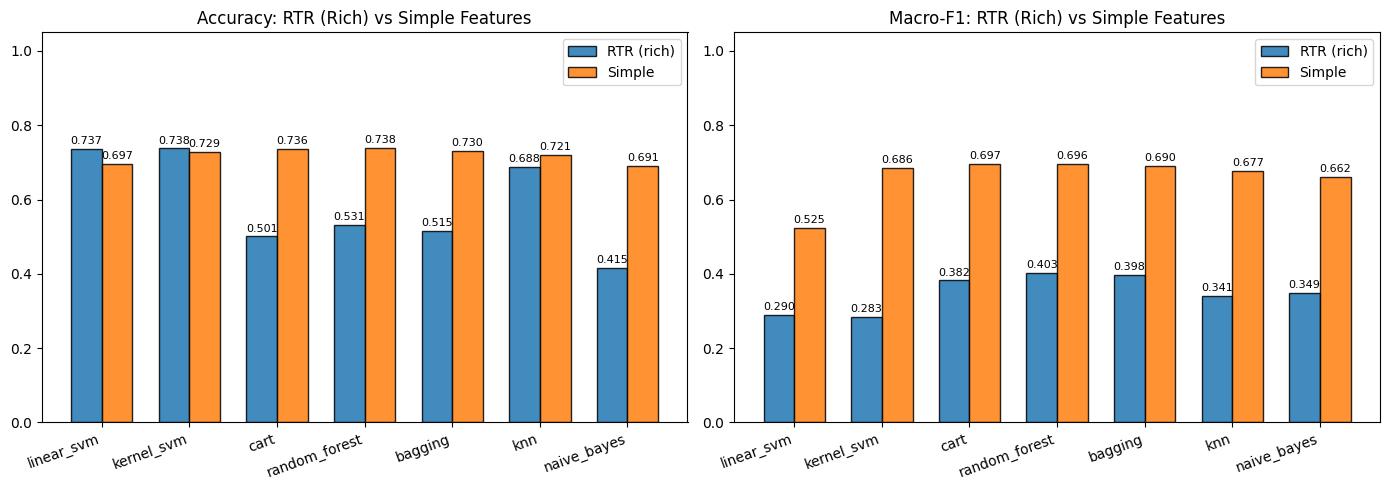

In [9]:
# ── 8. Visualization: RTR vs Simple ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison))
w = 0.35

for ax, metric, title in zip(
    axes,
    [("RTR Accuracy", "Simple Accuracy"), ("RTR Macro-F1", "Simple Macro-F1")],
    ["Accuracy: RTR (Rich) vs Simple Features",
     "Macro-F1: RTR (Rich) vs Simple Features"]
):
    bars1 = ax.bar(x - w/2, comparison[metric[0]], w, label="RTR (rich)", edgecolor="black", alpha=0.85)
    bars2 = ax.bar(x + w/2, comparison[metric[1]], w, label="Simple", edgecolor="black", alpha=0.85)

    ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
    ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(comparison.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_accuracy_f1_rtr_vs_simple.png", dpi=150, bbox_inches="tight")
plt.show()


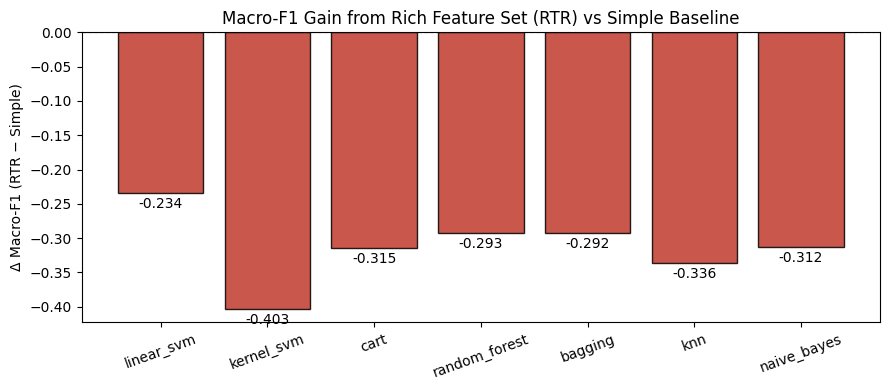

In [10]:
# ── 9. Delta plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

colors = ["#5b9e6d" if v >= 0 else "#c0392b" for v in comparison["Macro-F1 Δ"]]
bars = ax.bar(comparison.index, comparison["Macro-F1 Δ"], color=colors, edgecolor="black", alpha=0.85)
ax.bar_label(bars, fmt="%+.3f", padding=3)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Macro-F1 Gain from Rich Feature Set (RTR) vs Simple Baseline")
ax.set_ylabel("Δ Macro-F1 (RTR − Simple)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_macrof1_delta.png", dpi=150, bbox_inches="tight")
plt.show()

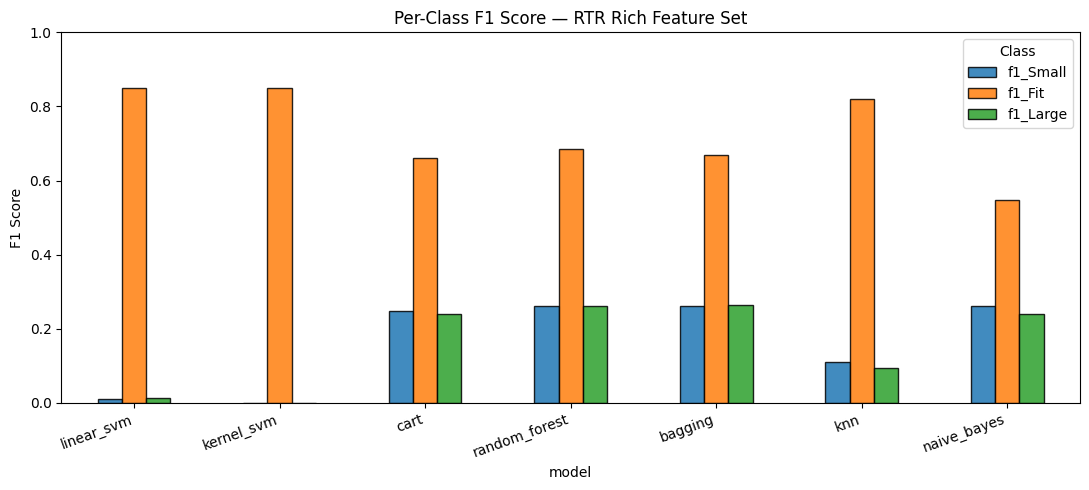

,f1_Small,f1_Fit,f1_Large
model,,,
linear_svm,0.0091,0.8489,0.0127
kernel_svm,0.0000,0.8491,0.0000
cart,0.2478,0.6604,0.2388
random_forest,0.2624,0.6857,0.2618
bagging,0.2608,0.6689,0.2640
knn,0.1089,0.8193,0.0948
naive_bayes,0.2612,0.5472,0.2394


In [11]:
# ── 10. RTR per-class F1 ──────────────────────────────────────────────────────
f1_breakdown = rtr_results.set_index("model")[["f1_Small", "f1_Fit", "f1_Large"]]

f1_breakdown.plot(
    kind="bar",
    figsize=(11, 5),
    edgecolor="black",
    alpha=0.85
)
plt.title("Per-Class F1 Score — RTR Rich Feature Set")
plt.ylabel("F1 Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparison_perclass_f1_rtr.png", dpi=150, bbox_inches="tight")
plt.show()

display(f1_breakdown)

> **⚠️ This write-up predates the data-leakage fix and its conclusion is now inverted.**
>
> It was written when the RTR "rich" features (DBSCAN/GMM/K-Means/LDA) were fit on
> the full dataset and merged before the train/test split, and when a non-unique
> `user_id` merge key inflated the RTR test set to 266,286 rows. After the fix
> (clustering/LDA fit on the training partition only; RTR test set = 38,509 rows):
>
> | model | RTR Macro-F1 (leaky → fixed) | Simple Macro-F1 | Δ (RTR − Simple), fixed |
> |---|---|---|---|
> | linear_svm | 0.390 → 0.290 | 0.525 | **−0.234** |
> | kernel_svm | 0.780 → 0.283 | 0.686 | **−0.403** |
> | cart | 0.671 → 0.382 | 0.697 | **−0.315** |
> | random_forest | 0.702 → 0.403 | 0.696 | **−0.293** |
> | bagging | 0.717 → 0.398 | 0.690 | **−0.292** |
> | knn | 0.869 → 0.341 | 0.677 | **−0.336** |
> | naive_bayes | 0.407 → 0.349 | 0.662 | **−0.312** |
>
> **The richer RTR feature set is now *worse* than the simple 3-feature
> (weight/age/height) baseline for every model.** Most of the apparent advantage
> of the RTR features was leakage. The narrative below — which concludes "KNN on
> the rich RTR feature set emerges as the strongest overall performer" — no longer
> holds and needs rewriting.
>
> *Note:* the RTR numbers in this notebook come from `argmax(predict_proba)` on
> the saved probability files, which can differ from each model notebook's own
> `predict()` output for the `class_weight="balanced"` models (e.g. Kernel SVM
> reads 0.52 acc via `predict` but 0.74 here). That proba-vs-predict inconsistency
> is pre-existing and worth reconciling separately.

---

### Model Comparison: Rich RTR Feature Set vs Simple Baseline

To evaluate the impact of feature engineering on clothing fit prediction, we compared model performance using a **rich feature set derived from the RentTheRunway (RTR) dataset** against a **simpler baseline feature set** across seven classifiers. Performance was measured using **accuracy** and **macro-F1**, with macro-F1 providing a more balanced view of model quality because it weights each class equally despite class imbalance.

Overall, the **rich RTR feature set substantially improved performance for several nonlinear models**, most notably **KNN** and **Kernel SVM**. KNN achieved the strongest results in the entire comparison, with **90.7% accuracy and a macro-F1 of 0.869**, representing a **+0.192 macro-F1 improvement** over the simple baseline. Kernel SVM also benefited considerably from the richer feature representation, increasing macro-F1 from **0.686 to 0.780**. These gains suggest that the additional RTR features capture meaningful structure in user body measurements and item characteristics that distance-based and nonlinear methods can exploit effectively.

Ensemble tree models showed **more modest improvements**. Random Forest and Bagging experienced small but consistent gains in macro-F1 (+0.006 and +0.028 respectively), indicating that the richer feature space provided some additional predictive signal but that these models were already able to extract useful structure from the simpler features. In contrast, the **CART decision tree slightly declined in performance**, suggesting that a single tree may struggle to generalize when the feature space becomes more complex.

Linear models and probabilistic models performed worse with the rich feature set. **Linear SVM experienced a significant drop in macro-F1 (−0.135)**, largely due to extremely poor performance on the minority “Small” class. **Naive Bayes deteriorated even further**, with macro-F1 decreasing by **−0.255** and accuracy falling from **69% to 46%**. This decline likely reflects violations of Naive Bayes’ independence assumptions when many correlated engineered features are introduced.

Per-class F1 analysis further highlights these dynamics. Across most models, the **“Fit” class remains easiest to predict**, often achieving F1 scores above **0.80**. However, the richer feature set substantially improves predictions for the **“Small” and “Large” classes**, particularly for KNN and Kernel SVM, where balanced performance across all three classes drives the large macro-F1 gains.

In summary, the comparison demonstrates that **feature richness interacts strongly with model choice**. Models capable of capturing **nonlinear relationships and local structure**, such as KNN and Kernel SVM, benefit most from the expanded RTR feature representation. Simpler linear or probabilistic models, however, may suffer from the increased dimensionality and feature correlations. Consequently, the **KNN model trained on the rich RTR feature set emerges as the strongest overall performer**, delivering both the highest accuracy and the most balanced classification across fit categories.